# Air Passenger Forecasting using Deep Learning (LSTM & GRU)

## **Dataset Description:**
### The 'AirPassengers' dataset contains monthly totals of international airline passengers from January 1949 to December 1960.

### **Dataset features**
*   Month – Date of observation (monthly frequency)

*   Passengers – Number of airline passengers

## Goal of the Project:
### The goal of this project is to forecast the number of airline passengers for the next 6 months and 12 months using LSTM and GRU.



---

# **1. Imporing libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM, GRU, Input
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_error

import time

# **2. Inspecting dataset**

In [6]:
df = pd.read_csv('AirPassengers.csv')
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [7]:
df.tail()

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


- Dataset contains 144 rows

# 3. **Data Preprocessing**

## **a) Converting month to 'datetime' data type**

In [10]:
df['Month'] = pd.to_datetime(df['Month'])

## **b) Setting month as index**

In [11]:
df.set_index('Month', inplace=True)

In [12]:
df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

In [13]:
df = df.sort_index()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


# **4. Visualizing the data**

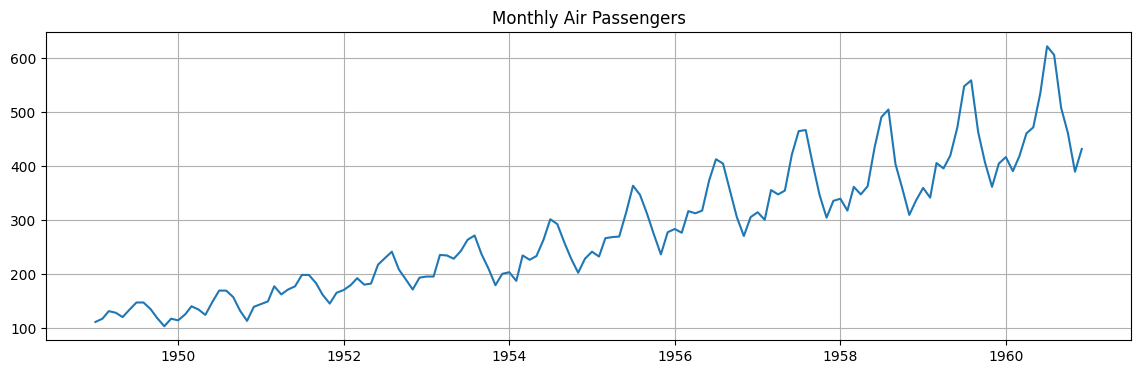

In [85]:
plt.figure(figsize=(14,4))
plt.plot(df['Passengers'])
plt.title("Monthly Air Passengers")
plt.grid()
plt.show()

# **5. Decomoposing the data into its components**

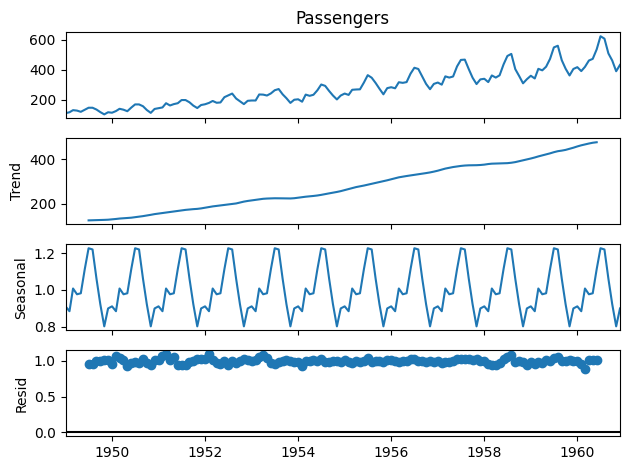

In [16]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

decomposition.plot()
plt.show()

# **6. Train test split**
- 70% training
- 30% testing

In [17]:
train_size = int(len(df) * 0.7)
train = df[0:train_size]
test = df[train_size:]

In [18]:
print(f"Train data size : {train.shape[0]}")
print(f"Test data size : {test.shape[0]}")

Train data size : 100
Test data size : 44


# **7. Normalizing the values**

In [19]:
scaler = MinMaxScaler()

train = scaler.fit_transform(train)
test = scaler.transform(test)

# **8. Defining look_back**
It defines how many previous time steps are used as input to predict the next value.

In [20]:
look_back=12

In [21]:
def get_data(data, look_back):
    dataX, dataY = [], []
    for i in range(len(data)-look_back-1):
        a = data[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(data[i+look_back, 0])
    return np.array(dataX), np.array(dataY)

In [22]:
X_train, y_train = get_data(train, look_back)
X_test,  y_test  = get_data(test, look_back)

In [23]:
X_train = X_train.reshape(X_train.shape[0], look_back, 1)
X_test  = X_test.reshape(X_test.shape[0],  look_back, 1)

# **9. Building LSTM model**

In [25]:
lstm_model = Sequential()

lstm_model.add(LSTM(128, return_sequences=True, input_shape=(look_back,1)))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 12, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

# **9. Training LSTM model**

In [27]:
start_time = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)
end_time = time.time()
lstm_training_time = end_time - start_time
print(f"LSTM Training Time: {lstm_training_time:.2f} seconds")

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1219
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0156
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0151
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0141
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0157
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0104
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0103
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0135
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0118
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0136
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0131
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0131
Epoch 13/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0120
Epoch 14/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0125
Epoch 15/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0118
Epoc

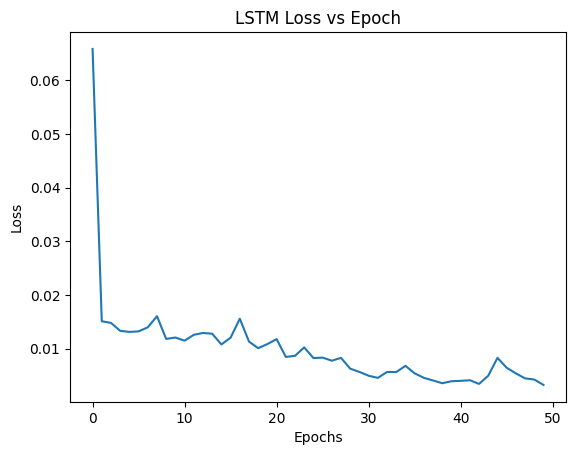

In [28]:
plt.plot(lstm_history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("LSTM Loss vs Epoch")
plt.show()

# **10. LSTM prediction**

In [29]:
train_pred = lstm_model.predict(X_train)
test_pred  = lstm_model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
y_train    = scaler.inverse_transform(y_train.reshape(-1,1))

test_pred  = scaler.inverse_transform(test_pred)
y_test     = scaler.inverse_transform(y_test.reshape(-1,1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [30]:
# ---- TRAIN METRICS ----
lstm_train_mae  = mean_absolute_error(y_train, train_pred)
lstm_train_mse  = mean_squared_error(y_train, train_pred)
lstm_train_rmse = np.sqrt(lstm_train_mse)

# ---- TEST METRICS ----
lstm_test_mae  = mean_absolute_error(y_test, test_pred)
lstm_test_mse  = mean_squared_error(y_test, test_pred)
lstm_test_rmse = np.sqrt(lstm_test_mse)

print("---------------------------------")
print("Train MAE :", lstm_train_mae)
print("Train RMSE:", lstm_train_rmse)

print("---------------------------------")

print("Test MAE :", lstm_test_mae)
print("Test RMSE:", lstm_test_rmse)
print("---------------------------------")

---------------------------------
Train MAE : 13.583358238483298
Train RMSE: 16.852930023071046
---------------------------------
Test MAE : 32.285184798702126
Test RMSE: 39.25792197652128
---------------------------------


The test metrics shows comparable results with training data, indicating that it has learned the training patterns effectively

# **Prediction on test data**

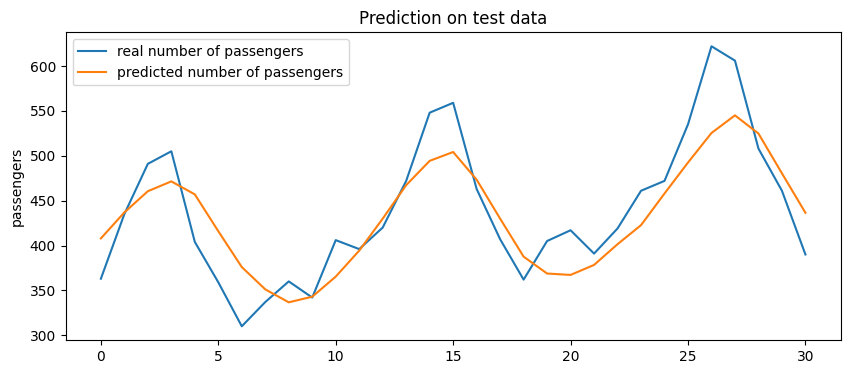

In [31]:
plt.figure(figsize=(10,4))
plt.plot(y_test, label = 'real number of passengers')
plt.plot(test_pred, label = 'predicted number of passengers')
plt.title("Prediction on test data")
plt.ylabel('passengers')
plt.legend()
plt.show()

# **11. Future forecast for using LSTM**

In [32]:
def forecast_future(model, last_sequence, n_steps, scaler):

    future_preds = []

    current_input = last_sequence.copy()

    for i in range(n_steps):

        current_input_reshaped = current_input.reshape(1,
                                                       current_input.shape[0],
                                                       1)

        next_pred = model.predict(current_input_reshaped,
                                  verbose=0)[0,0]

        future_preds.append(next_pred)

        # slide window forward
        current_input = np.append(current_input[1:], next_pred)

    future_preds = np.array(future_preds).reshape(-1,1)

    future_preds = scaler.inverse_transform(future_preds)

    return future_preds

In [33]:
last_input = X_test[-1]

In [34]:
future_6 = forecast_future(lstm_model, last_input, 6, scaler)
future_12 = forecast_future(lstm_model, last_input, 12, scaler)
future_24 = forecast_future(lstm_model, last_input, 24, scaler)

In [35]:
def get_future_dates(last_date, n_steps):

    future_dates = pd.date_range(start=last_date,
                                 periods=n_steps+1,
                                 freq='M')[1:]

    return future_dates

In [36]:
future_dates_6 = get_future_dates(df.index[-1], 6)
future_dates_12 = get_future_dates(df.index[-1], 12)
future_dates_24 = get_future_dates(df.index[-1], 24)

/tmp/ipykernel_491/633842813.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date,


# **Visualization on future dates**

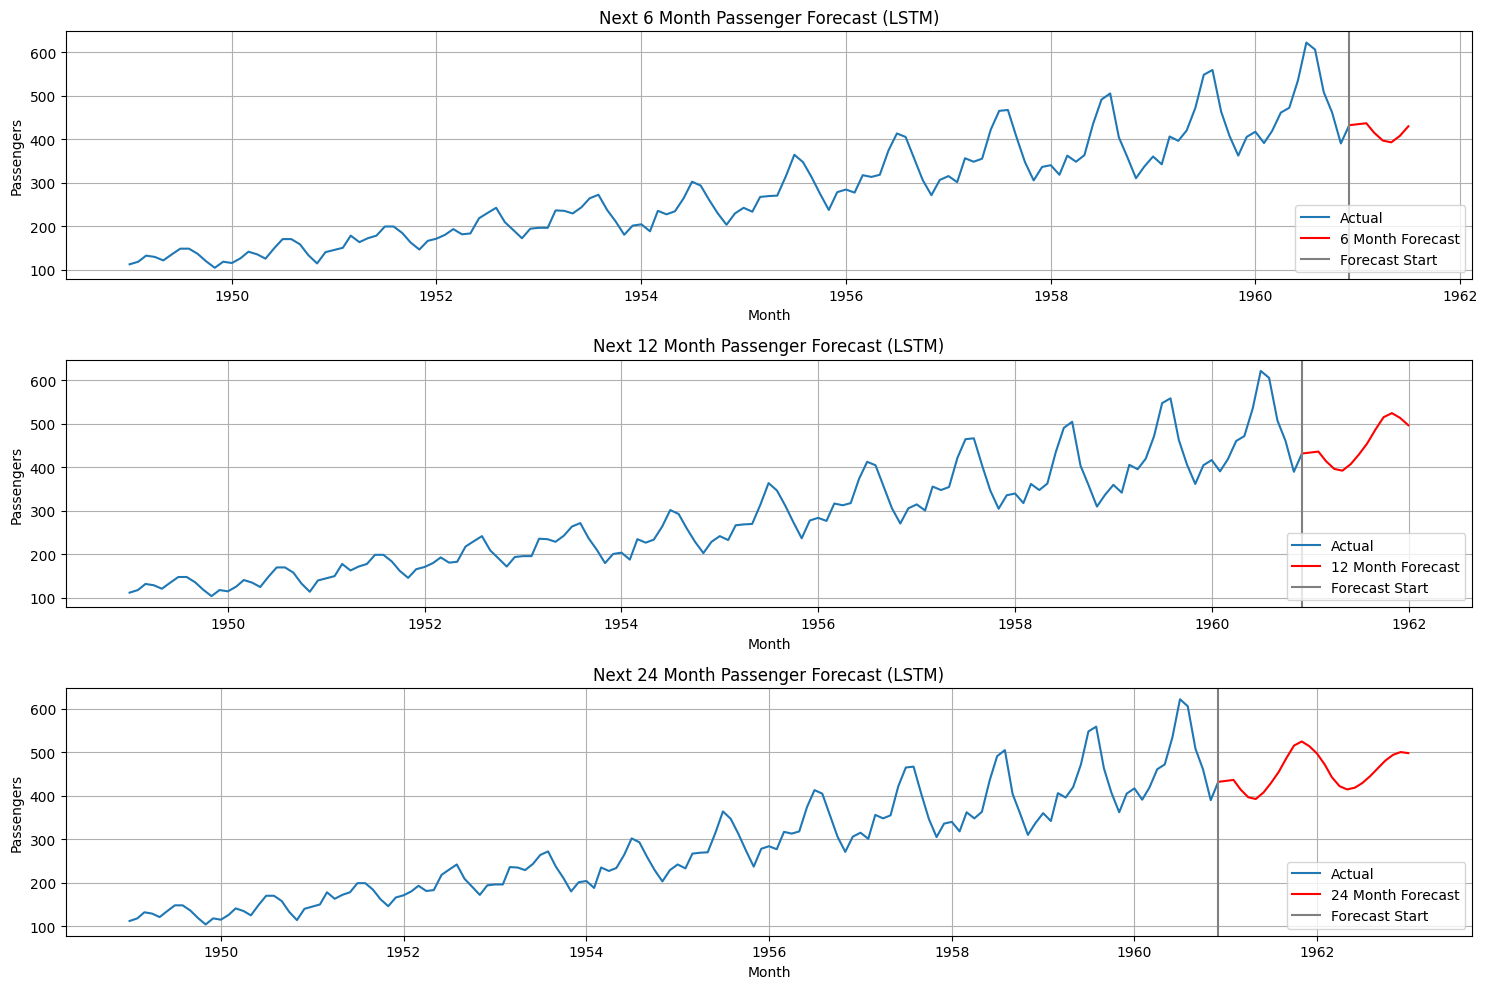

In [37]:
months = [6, 12, 24]

plt.figure(figsize=(15, 10))

for i, month in enumerate(months):
    plt.subplot(len(months), 1, i + 1) # Create a subplot for each month

    # Dynamically select the correct future_dates and future_data based on the month
    if month == 6:
        future_dates = future_dates_6
        future_data = future_6
    elif month == 12:
        future_dates = future_dates_12
        future_data = future_12
    elif month == 24:
        future_dates = future_dates_24
        future_data = future_24
    else:
        print(f"Warning: No forecast data found for {month} months. Skipping this plot.")
        continue # Skip to the next iteration if data is not found

    if future_data.ndim == 2 and future_data.shape[1] == 1:
        future_data = future_data.flatten() # or future_data = future_data[:, 0]
    elif future_data.ndim > 1:
        print(f"Warning: future_data for {month} months has more than 1 dimension ({future_data.ndim}). Attempting to flatten.")
        future_data = future_data.flatten()


    # --- Plotting the actual data ---
    plt.plot(df.index,
             df['Passengers'],
             label='Actual',
             color='tab:blue') # Explicitly set color for clarity

    # --- Plotting the forecast data, ensuring it starts from the last actual point ---
    last_actual_date = df.index[-1]
    last_actual_value = df['Passengers'].iloc[-1]

    if not isinstance(future_dates, pd.DatetimeIndex):
        future_dates = pd.to_datetime(future_dates) # Convert if it's not already

    forecast_x = pd.DatetimeIndex([last_actual_date]).append(future_dates)

    forecast_y = np.concatenate(([last_actual_value], future_data))

    plt.plot(forecast_x,
             forecast_y,
             color='red',
             label=f'{month} Month Forecast')

    plt.axvline(x=last_actual_date, color='gray', linestyle='-', linewidth=1.5, label='Forecast Start')


    plt.title(f"Next {month} Month Passenger Forecast (LSTM)")
    plt.xlabel("Month")
    plt.ylabel("Passengers")
    plt.legend(loc='lower right')
    plt.grid(True)

plt.tight_layout()
plt.show()

# **Saving the model**

In [38]:
lstm_model.save("lstm_model.keras")
print(f"LSTM model saved successfully")

LSTM model saved successfully


---

# **GRU**

In [53]:
X_train, y_train = get_data(train, look_back)
X_test,  y_test  = get_data(test, look_back)

In [54]:
X_train = X_train.reshape(X_train.shape[0], look_back, 1)
X_test  = X_test.reshape(X_test.shape[0],  look_back, 1)

# **1. GRU model architecture**

In [55]:
gru_model = Sequential()

gru_model.add(GRU(128, return_sequences=True, input_shape=(look_back,1)))
# gru_model.add(GRU(32))
gru_model.add(GRU(64))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [56]:
gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 12, 128)        │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,617 (342.25 KB)

 Trainable params: 87,617 (342.25 KB)

 Non-trainable params: 0 (0.00 B)

# **2. GRU training**

In [57]:
start_time = time.time()
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=8,
    verbose=1
)
end_time = time.time()
gru_training_time = end_time - start_time
print(f"GRU Training Time: {gru_training_time:.2f} seconds")

Epoch 1/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0891
Epoch 2/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0168
Epoch 3/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0148
Epoch 4/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0172
Epoch 5/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0162
Epoch 6/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0089
Epoch 7/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0120
Epoch 8/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0104
Epoch 9/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0101
Epoch 10/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0079
Epoch 11/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0107
Epoch 12/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0077
Epoch 13/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0102
Epoch 14/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0105
Epoch 15/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0084
Epoc

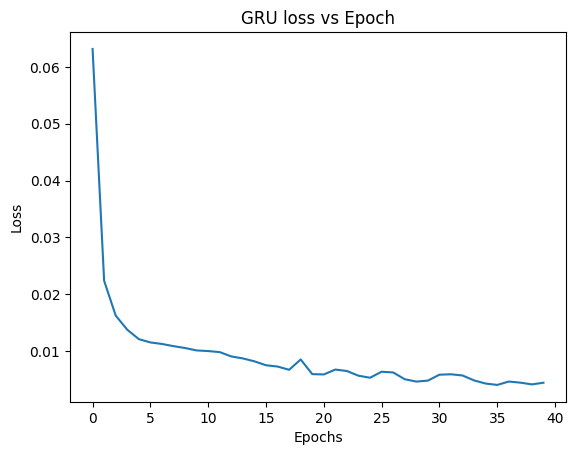

In [58]:
plt.plot(history_gru.history['loss'])
plt.title("GRU loss vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# **3. Prediction on test data using GRU**

In [59]:
train_pred = gru_model.predict(X_train)
test_pred  = gru_model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [46]:
train_pred.shape

(87, 1)

In [47]:
test_pred.shape

(31, 1)

In [60]:
train_pred = scaler.inverse_transform(train_pred)
y_train_inv    = scaler.inverse_transform(y_train.reshape(-1,1))

test_pred  = scaler.inverse_transform(test_pred)
y_test_inv     = scaler.inverse_transform(y_test.reshape(-1,1))

# **4. Evaluating GRU**

In [61]:
gru_train_mae  = mean_absolute_error(y_train_inv, train_pred)
gru_train_mse  = mean_squared_error(y_train_inv, train_pred)
gru_train_rmse = np.sqrt(gru_train_mse)

gru_test_mae  = mean_absolute_error(y_test_inv, test_pred)
gru_test_mse  = mean_squared_error(y_test_inv, test_pred)
gru_test_rmse = np.sqrt(gru_test_mse)

print("Train MAE :", gru_train_mae)
print("Train RMSE:", gru_train_rmse)
print("----------------------")
print("Test MAE :", gru_test_mae)
print("Test RMSE:", gru_test_rmse)

Train MAE : 16.034967795185658
Train RMSE: 18.7193315971769
----------------------
Test MAE : 31.192434003276215
Test RMSE: 37.98459174138682


# **5. Visualization on test data**

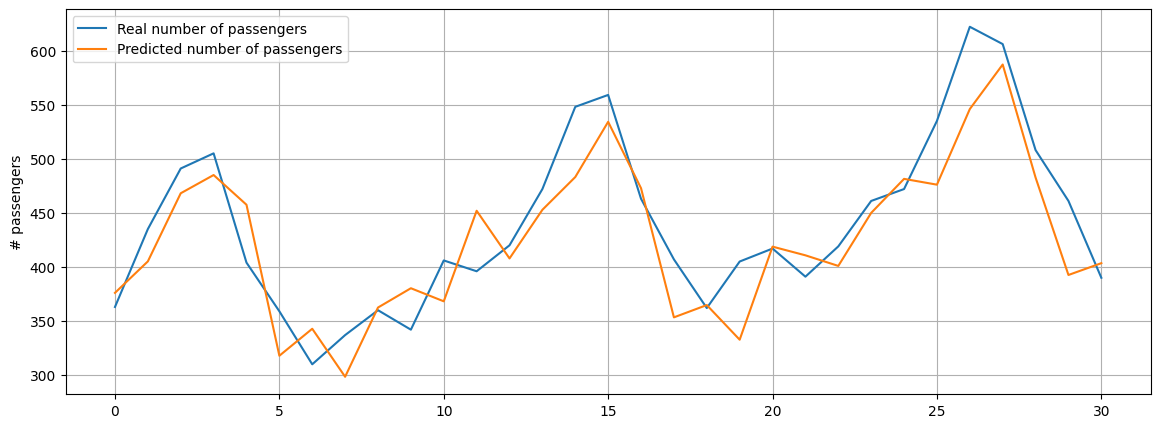

In [62]:
plt.figure(figsize=(14,5))
plt.plot(y_test_inv, label='Real number of passengers')
plt.plot(test_pred, label='Predicted number of passengers')
plt.ylabel('# passengers')
plt.legend()
plt.grid(True)
plt.show()

# **6. Future forecast using GRU**

In [63]:
future_6_gru  = forecast_future(gru_model, last_input, 6, scaler)
future_12_gru = forecast_future(gru_model, last_input, 12, scaler)
future_24_gru = forecast_future(gru_model, last_input, 24, scaler)

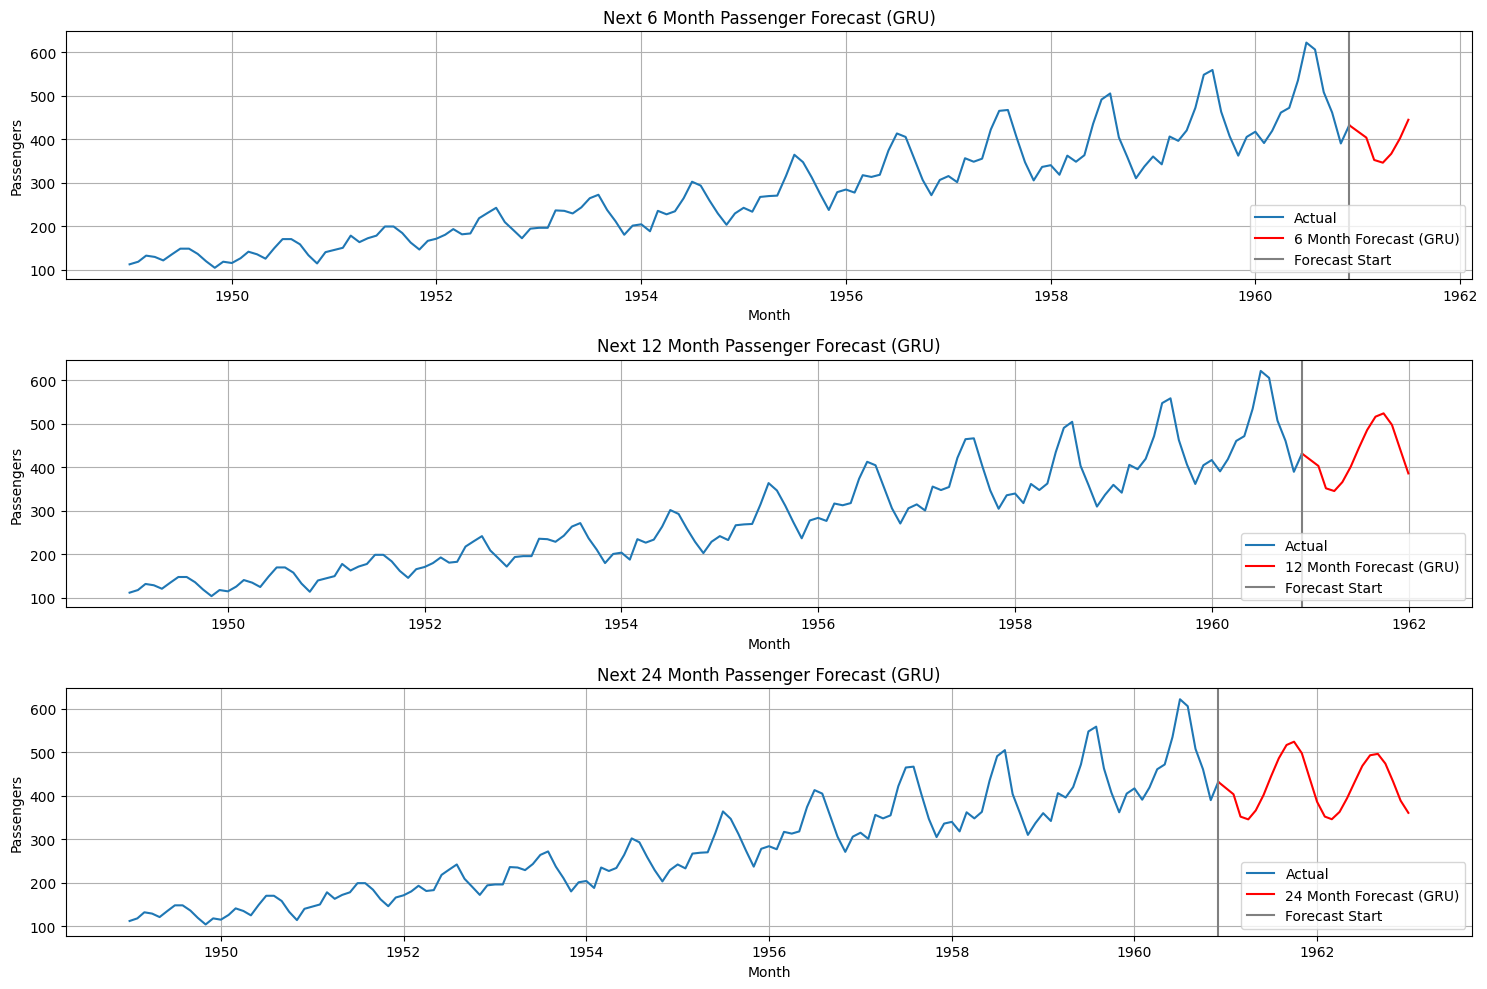

In [64]:
months = [6, 12, 24]

plt.figure(figsize=(15, 10))

for i, month in enumerate(months):
    plt.subplot(len(months), 1, i + 1)

    if month == 6:
        future_dates = future_dates_6
        future_data = future_6_gru
    elif month == 12:
        future_dates = future_dates_12
        future_data = future_12_gru
    elif month == 24:
        future_dates = future_dates_24
        future_data = future_24_gru

    else:
        continue

    # Flatten if needed
    if future_data.ndim == 2 and future_data.shape[1] == 1:
        future_data = future_data.flatten()

    # Actual data
    plt.plot(df.index,
             df['Passengers'],
             label='Actual',
             color='tab:blue')

    last_actual_date = df.index[-1]
    last_actual_value = df['Passengers'].iloc[-1]

    forecast_x = pd.DatetimeIndex([last_actual_date]).append(future_dates)
    forecast_y = np.concatenate(([last_actual_value], future_data))

    plt.plot(forecast_x,
             forecast_y,
             color='red',
             label=f'{month} Month Forecast (GRU)')

    plt.axvline(x=last_actual_date,
                color='gray',
                linestyle='-',
                linewidth=1.5,
                label='Forecast Start')

    plt.title(f"Next {month} Month Passenger Forecast (GRU)")
    plt.xlabel("Month")
    plt.ylabel("Passengers")
    plt.legend(loc='lower right')
    plt.grid(True)

plt.tight_layout()
plt.show()

# **7. Saving GRU model**

In [65]:
gru_model.save("gru_model.keras")
print(f"GRU model saved successfully")

GRU model saved successfully


---

# **Comparison**

# **1. Future forecast of GRU and LSTM**

In [72]:
forecast_passengers = pd.DataFrame({
    "GRU": future_24_gru.flatten(),
    "LSTM": future_24.flatten()
})

In [73]:
forecast_passengers

,GRU,LSTM
0,403.477295,436.476288
1,351.993561,414.607635
2,345.750519,396.606232
3,366.324615,392.536591
4,401.603363,407.599426
5,444.493011,429.514954
6,486.141327,455.112366
7,516.787781,487.334106
8,524.405640,515.594788
9,498.056915,524.885071


# **2. Metric comparison**

In [66]:
performance_df = pd.DataFrame({

    'Model': ['LSTM', 'GRU'],

    'Train MAE': [
        lstm_train_mae,
        gru_train_mae
    ],

    'Train RMSE': [
        lstm_train_rmse,
        gru_train_rmse
    ],

    'Test MAE': [
        lstm_test_mae,
        gru_test_mae
    ],

    'Test RMSE': [
        lstm_test_rmse,
        gru_test_rmse
    ],

    'Training Time (seconds)': [
        lstm_training_time,
        gru_training_time
    ]
})

performance_df

,Model,Train MAE,Train RMSE,Test MAE,Test RMSE,Training Time (seconds)
0,LSTM,13.583358,16.852930,32.285185,39.257922,13.939355
1,GRU,16.034968,18.719332,31.192434,37.984592,13.897793


# **3. Training time**

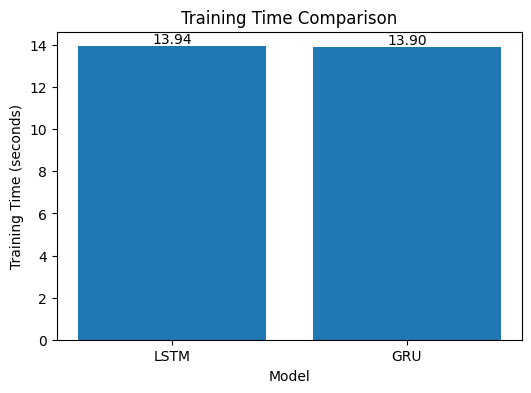

In [67]:
models = ['LSTM', 'GRU']
training_times = [lstm_training_time, gru_training_time]

# Create figure
plt.figure(figsize=(6,4))

bars = plt.bar(models, training_times)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}',
             ha='center',
             va='bottom')

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

plt.show()

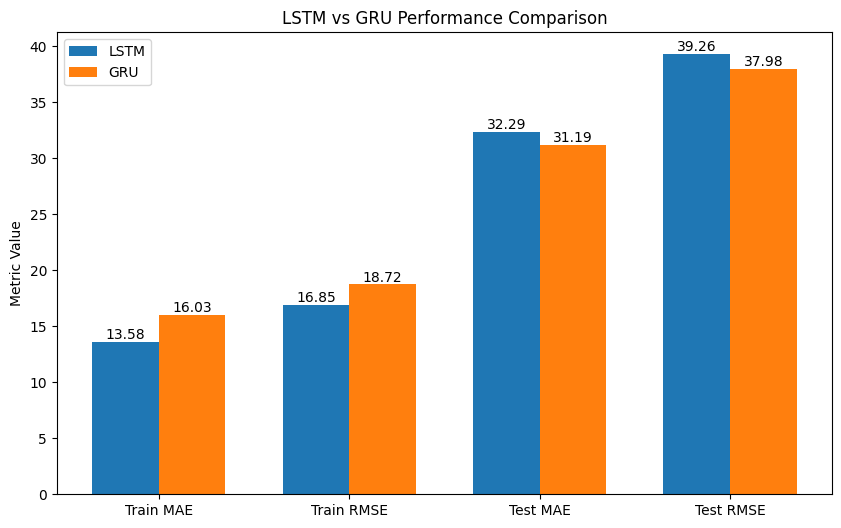

In [68]:
labels = ['Train MAE', 'Train RMSE', 'Test MAE', 'Test RMSE']

lstm_values = [
    lstm_train_mae,
    lstm_train_rmse,
    lstm_test_mae,
    lstm_test_rmse
]

gru_values = [
    gru_train_mae,
    gru_train_rmse,
    gru_test_mae,
    gru_test_rmse
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, lstm_values, width, label='LSTM')
bars2 = plt.bar(x + width/2, gru_values, width, label='GRU')

# Add values on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{height:.2f}',
                 ha='center',
                 va='bottom')

plt.xticks(x, labels)
plt.ylabel('Metric Value')
plt.title('LSTM vs GRU Performance Comparison')
plt.legend()

plt.show()

# **Conclusion:**
- Both LSTM and GRU models were implemented using the same neural network architecture to ensure a fair comparison.

- The LSTM model was trained for 50 epochs, while the GRU model was trained for 40 epochs.

- After evaluating the models using performance using metrics MAE and RMSE, it was observed that the GRU model produced better prediction results and achieved lower loss values compared to the LSTM model.

- This indicates that for this dataset, the GRU model was able to learn the temporal patterns more efficiently and generalize slightly better for forecasting future passenger values.

Overall, both models successfully captured the time-series patterns, but GRU demonstrated better performance for forecasting the future passenger counts.